## **Binary Classification**

In this case $y = {0,1}$. SVMs work better with $y = {-1,1}$.

**Binary Cross-Entropy Loss Function**

THis is the most common loss function for binary classification. Logistic Regression, Neural Nets use this loss function. It uses the natural log function of the probabilities obtained in the model. We want the loss of every observation to be as close to zero as possible.

In [ ]:
## let's understand the log (ln)
import numpy as np

## the closer p is to zero, the larger |ln(p)| is.
## the closer p is to one, the smaller |ln(p)| is
## because  0<p<1 we will have negative values, we will use -ln(p) to get positive values
-np.log(0.9999)

np.float64(0.00010000500033334732)

In [ ]:
## suppose y = {1: fraud, 0: non-fraud}
p = 0.05
## this calculation is performed for the binary cross-entropy
-np.log(p)

np.float64(2.995732273553991)

In [ ]:
## Example
y = 0  # (fraudulent transaction)
p = 0.999

-(y*np.log(p) + (1-y)*np.log(1-p))

np.float64(6.907755278982136)

**Binary Cross-Entropy Cost Function**

Defined as the mean (average) of the binary cross-entropy loss.

In [ ]:
## function for binary cross-entropy loss
def binary_crossentropy(y_true, p_hat):
  return -(y_true*np.log(p_hat) + (1-y_true)*np.log(1-p_hat))

In [ ]:
y = 0  # (fraudulent transaction)
p = 0.999

binary_crossentropy(y, p)

np.float64(6.907755278982136)

In [ ]:
## function for binary cross-entropy cost
def binary_crossentropy_cost(y_true, p_hat):   ## assuming y_true and p_hat are vectors
  return np.mean(binary_crossentropy(y_true, p_hat))

In [ ]:
## Example
## cost function
y_true = np.array([0,   0,   0,   1,   1])
p_hat = np.array( [0.1, 0.2, 0.9, 0.7, 0.45])

binary_crossentropy_cost(y_true, p_hat)

np.float64(0.7572543600245172)

In [ ]:
## loss function
binary_crossentropy(y_true, p_hat)

array([0.10536052, 0.22314355, 2.30258509, 0.35667494, 0.7985077 ])

## **Example of Binary Classification**

In [ ]:
import pandas as pd

df = pd.read_csv('https://raw.githubusercontent.com/martinwg/ISA630/refs/heads/master/data/bank.csv')
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no
3,30,management,married,tertiary,no,1476,yes,yes,unknown,3,jun,199,4,-1,0,unknown,no
4,59,blue-collar,married,secondary,no,0,yes,no,unknown,5,may,226,1,-1,0,unknown,no


In [ ]:
## y counts
## binary problem (imbalanced or not) -
df.y.value_counts() / len(df)


,count
y,
no,0.88476
yes,0.11524


In [ ]:
## map from no, yes to 0, 1
y = df.y.map({'no': 0, "yes": 1})

In [ ]:
y

,y
0,0
1,0
2,0
3,0
4,0
...,...
4516,0
4517,0
4518,0
4519,0


In [ ]:
## cost function (binary crossentropy)
## p < 0.5 for everyone - 0.88

In [ ]:
## Create X and y
X = df.drop('y', axis=1)
# y = df.y

In [ ]:
## encode y to 0 and 1
# y = y.map({'no':0, 'yes':1})

In [ ]:
## Dummy encoding
X = pd.get_dummies(X, drop_first=True, dtype = int)

In [ ]:
X.shape

(4521, 42)

In [ ]:
## split 80% training and 20% test
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=630)

In [ ]:
X_train.shape, X_test.shape

((3616, 42), (905, 42))

**Logistic Regression**

Linear model with binary_crossentropy as the cost function. Gradient is non-convex, so we have to give steps. So, we need:

* n_iter, max_iter
* converges (means achieves a min - gradient 0) or not (does not get to a min - gradient not zeros)
* step size (learning rate)
* regularization - L1 penalty, L2 penalty

In [ ]:
from sklearn.linear_model import LogisticRegression


## no regularization
lr = LogisticRegression(penalty = None)

## fit
lr.fit(X_train, y_train)

## prediction
y_pred1 = lr.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


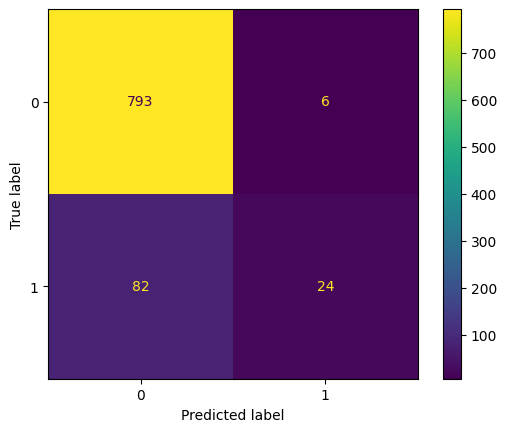

In [ ]:
## confusion matrix, accuracy,
from sklearn.metrics import confusion_matrix, accuracy_score, ConfusionMatrixDisplay, recall_score, balanced_accuracy_score

ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred1)).plot()

In [ ]:
accuracy_score(y_test, y_pred1 )

0.9027624309392265

In [ ]:
accuracy_score(y_test, y_pred1)

0.9027624309392265

In [ ]:
from sklearn.metrics import balanced_accuracy_score

balanced_accuracy_score(y_test, y_pred1)

np.float64(0.609452853803103)

In [ ]:
y.value_counts() / len(y)

,count
y,
0,0.88476
1,0.11524


In [ ]:
## if y is NOT ENCODED, we need to specify the positive class (interest)
## recall_score(y_test, y_pred1, pos_label = "yes")
recall_score(y_test, y_pred1)

0.22641509433962265

**Neural Network**

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras.optimizers import Adam

In [ ]:
## skeleton
nn = Sequential()

## Input Layer (size = number of variables - tuple)
nn.add(Input(shape = (X_train.shape[1],)))
## Hidden Layer 1 (32 neurons)
nn.add(Dense(32, activation = "relu"))
nn.add(Dropout(0.2)) ## regularize
## Hidden Layer 2 (16 neurons)
nn.add(Dense(16, activation = "relu"))
nn.add(Dropout(0.2)) ## regularize
## Hidden Layer 3 (8 neurons)
nn.add(Dense(8, activation = "relu"))
nn.add(Dropout(0.2)) ## regularize

## IMPORTANT LAYER (1 NEURON FOR BINARY CLASSIFICATION - ACTIVATION: SIGMOID)
nn.add(Dense(1, activation = "sigmoid"))

In [ ]:
nn.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │         1,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,049 (8.00 KB)

 Trainable params: 2,049 (8.00 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
## COMPILE
#### loss function
#### optimizer option (learning rate)
#### metrics
nn.compile(loss = "binary_crossentropy", optimizer = Adam(), metrics = ["accuracy"])

In [ ]:
## FIT
#### batch size (gradient descent)
#### epochs (number of times the gd goes through all the data)
#### if you want to monitor a validation data
history = nn.fit(X_train, y_train, epochs = 40, batch_size=32, validation_data = (X_test, y_test))

Epoch 1/40
113/113 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.5945 - loss: 24.9209 - val_accuracy: 0.8818 - val_loss: 4.8136
Epoch 2/40
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7012 - loss: 9.1889 - val_accuracy: 0.8442 - val_loss: 1.9176
Epoch 3/40
113/113 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.7279 - loss: 3.6700 - val_accuracy: 0.7691 - val_loss: 1.0207
Epoch 4/40
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7734 - loss: 2.0450 - val_accuracy: 0.8829 - val_loss: 0.5124
Epoch 5/40
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8382 - loss: 1.7543 - val_accuracy: 0.8829 - val_loss: 0.5036
Epoch 6/40
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8735 - loss: 0.9801 - val_accuracy: 0.8829 - val_loss: 0.4756
Epoch 7/40
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8655 - loss: 0.7645 - val_accuracy: 0.8829 - val_loss: 0.4631
Epoch 8/40
113/113 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.8736 - loss: 0.7452 - val_accuracy:

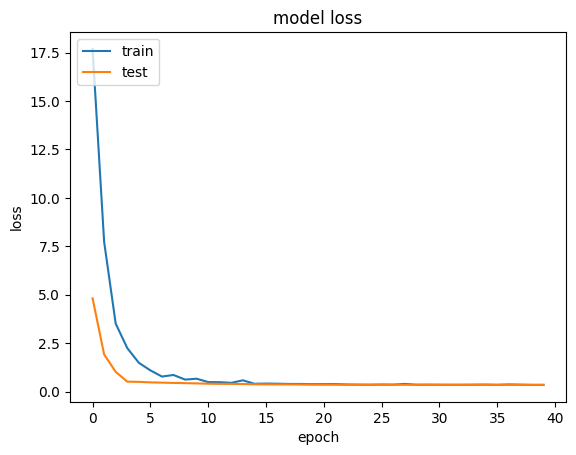

In [ ]:
## plot the learning curve
import matplotlib.pyplot as plt
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()